In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
#Load Data
data_path = r"C:\Users\Rahmah Adnan\Desktop\SeoulBikeData.csv"
df = pd.read_csv(data_path, encoding="unicode_escape")
print(df.shape)

(8760, 14)


In [4]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [5]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [6]:
#Data Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


In [8]:
#Check Null Value
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [9]:
df["Date"]= pd.to_datetime(df["Date"], format="%d/%m/%Y")

df["Weekday"]=df["Date"].dt.day_name()
df["Day"]=df["Date"].dt.day
df["Month"]=df["Date"].dt.month
df["Year"]=df["Date"].dt.year

df.drop("Date", axis=1, inplace=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          8760 non-null   int64  
 1   Hour                       8760 non-null   int64  
 2   Temperature(°C)            8760 non-null   float64
 3   Humidity(%)                8760 non-null   int64  
 4   Wind speed (m/s)           8760 non-null   float64
 5   Visibility (10m)           8760 non-null   int64  
 6   Dew point temperature(°C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)    8760 non-null   float64
 8   Rainfall(mm)               8760 non-null   float64
 9   Snowfall (cm)              8760 non-null   float64
 10  Seasons                    8760 non-null   str    
 11  Holiday                    8760 non-null   str    
 12  Functioning Day            8760 non-null   str    
 13  Weekday                    8760 non-null   str    
 14  Day

In [10]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Weekday,Day,Month,Year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017


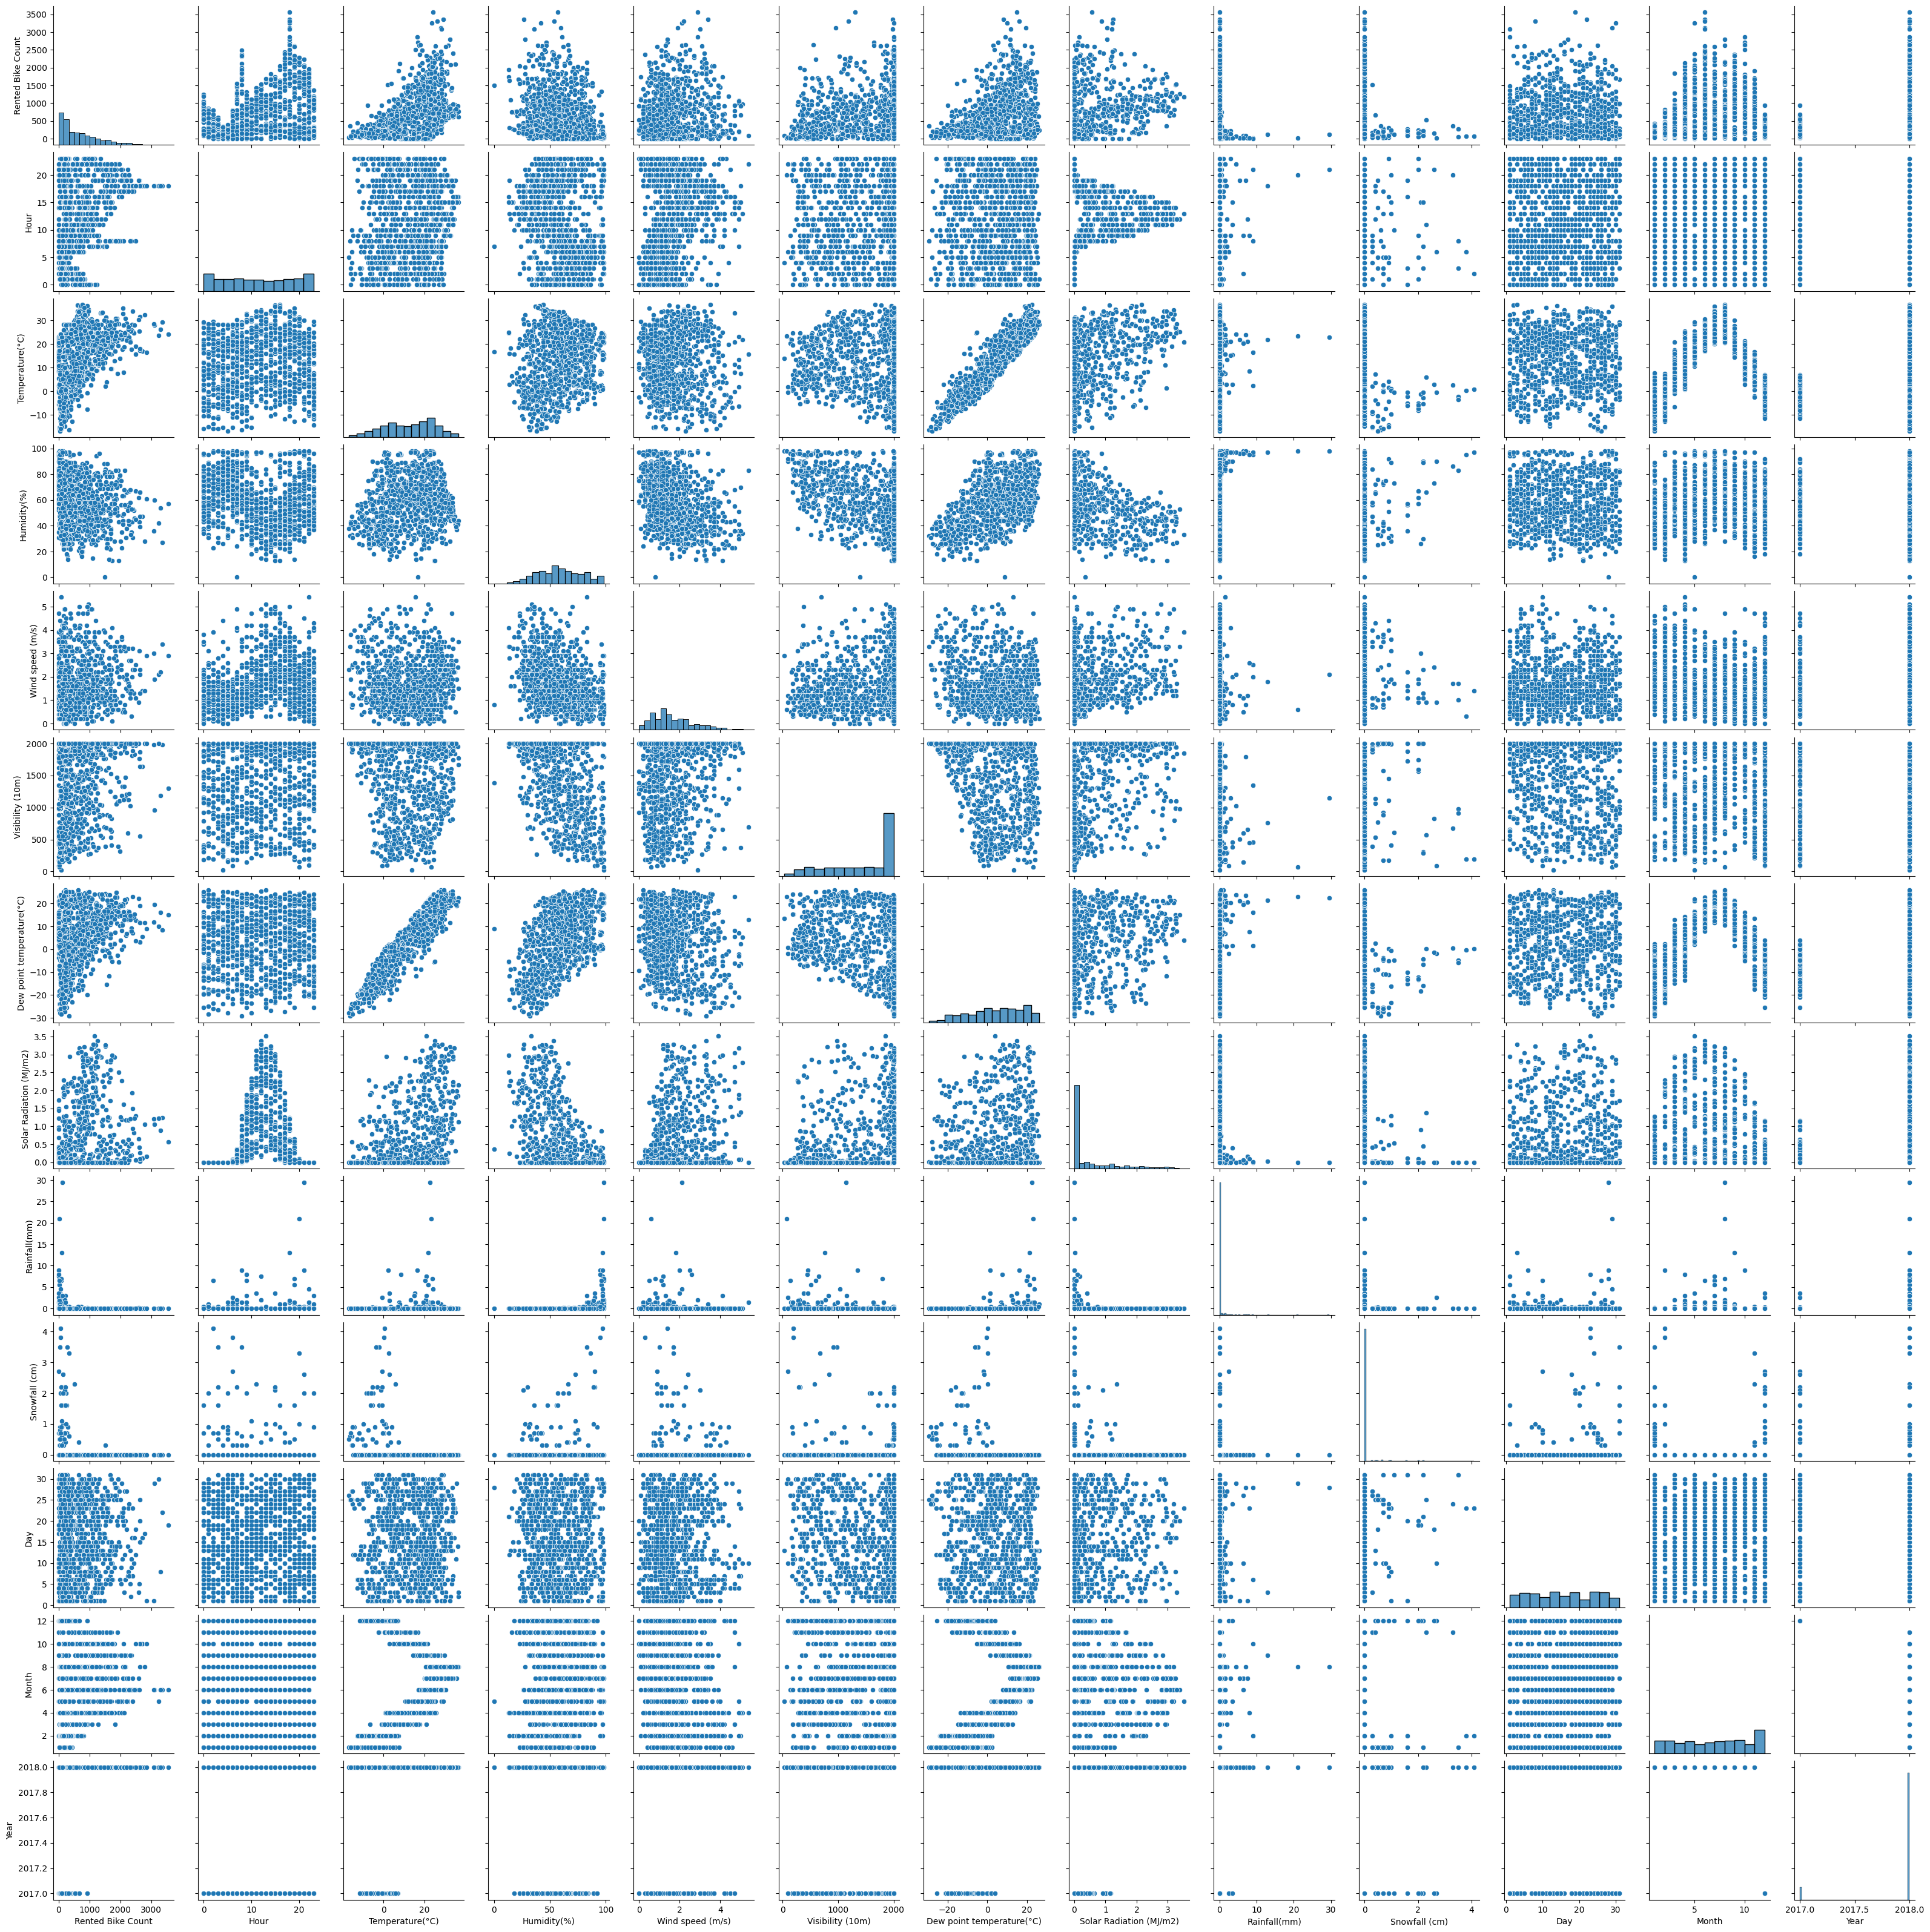

In [11]:
#EDA
sample_df = df.sample(1000, random_state=42)
sns.pairplot(sample_df)
plt.show()

<Axes: xlabel='Month', ylabel='Rented Bike Count'>

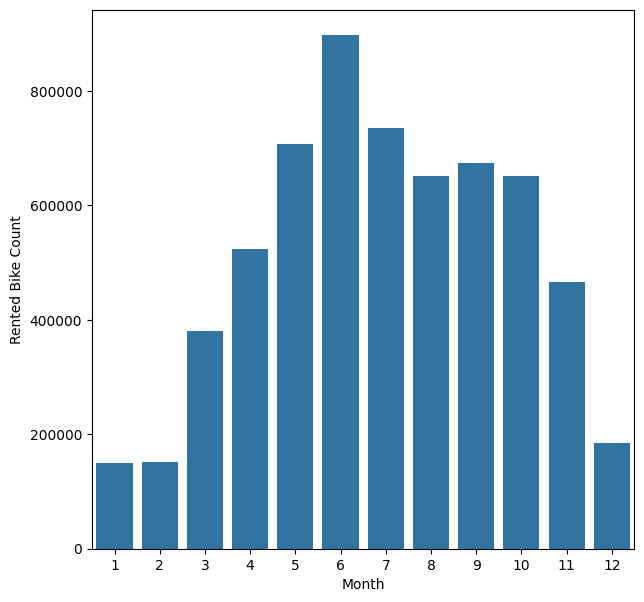

In [12]:
plt.figure(figsize=(7,7))
Month = df.groupby("Month").sum().reset_index()
sns.barplot(x="Month",y="Rented Bike Count", data=Month)

<Axes: xlabel='Day', ylabel='Rented Bike Count'>

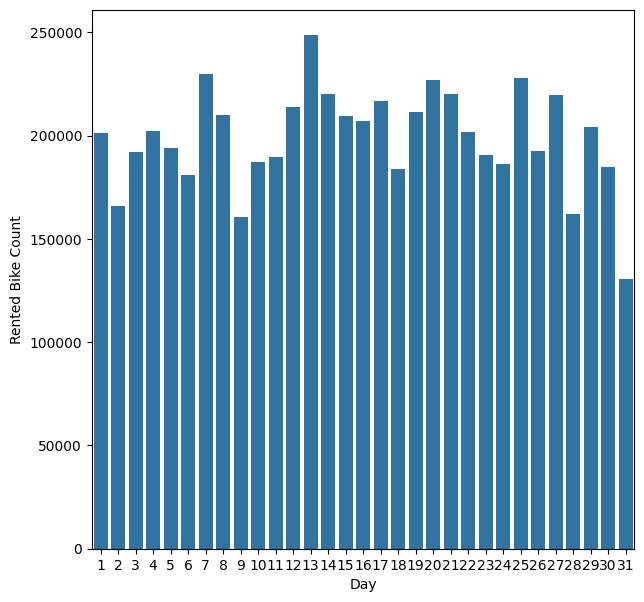

In [13]:
plt.figure(figsize=(7,7))
Day = df.groupby("Day").sum().reset_index()
sns.barplot(x="Day",y="Rented Bike Count", data=Day)

<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

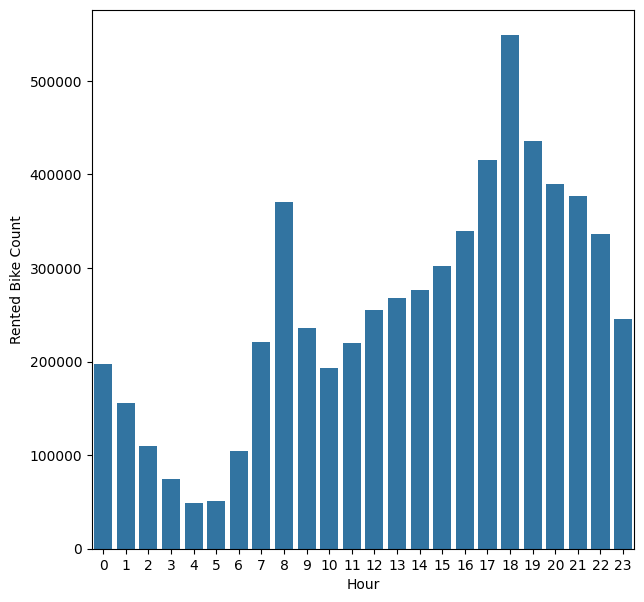

In [14]:
plt.figure(figsize=(7,7))
Hour = df.groupby("Hour").sum().reset_index()
sns.barplot(x="Hour",y="Rented Bike Count", data=Hour)

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

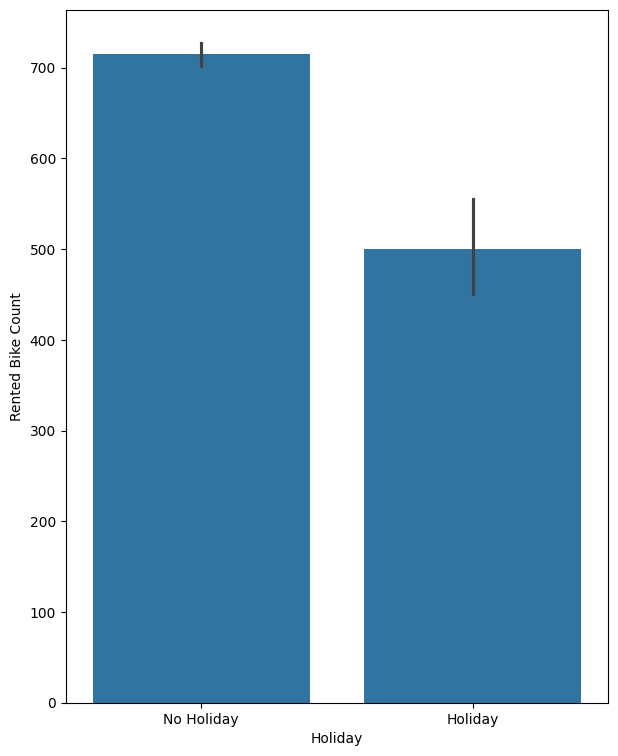

In [15]:
plt.figure(figsize=(7,9))
sns.barplot(x="Holiday",y="Rented Bike Count", data=df)

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

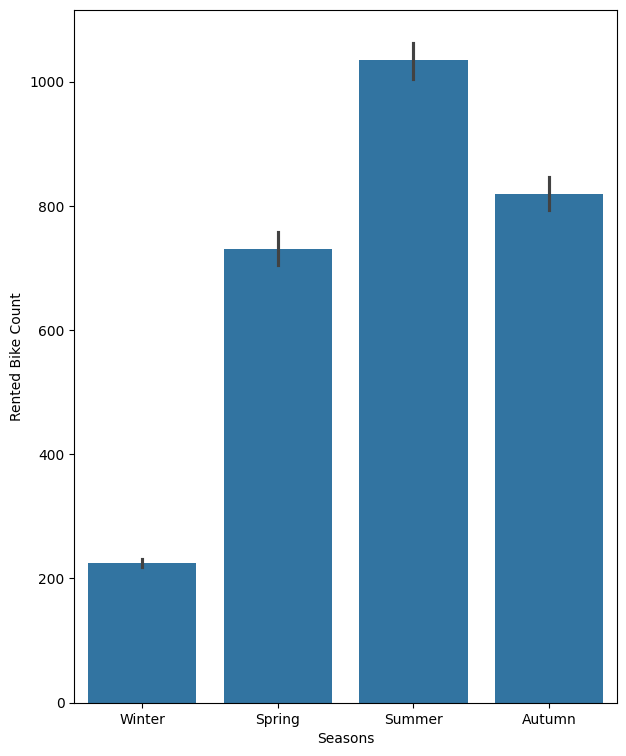

In [16]:
plt.figure(figsize=(7,9))
sns.barplot(x="Seasons",y="Rented Bike Count", data=df)

<Axes: xlabel='Rainfall(mm)', ylabel='Rented Bike Count'>

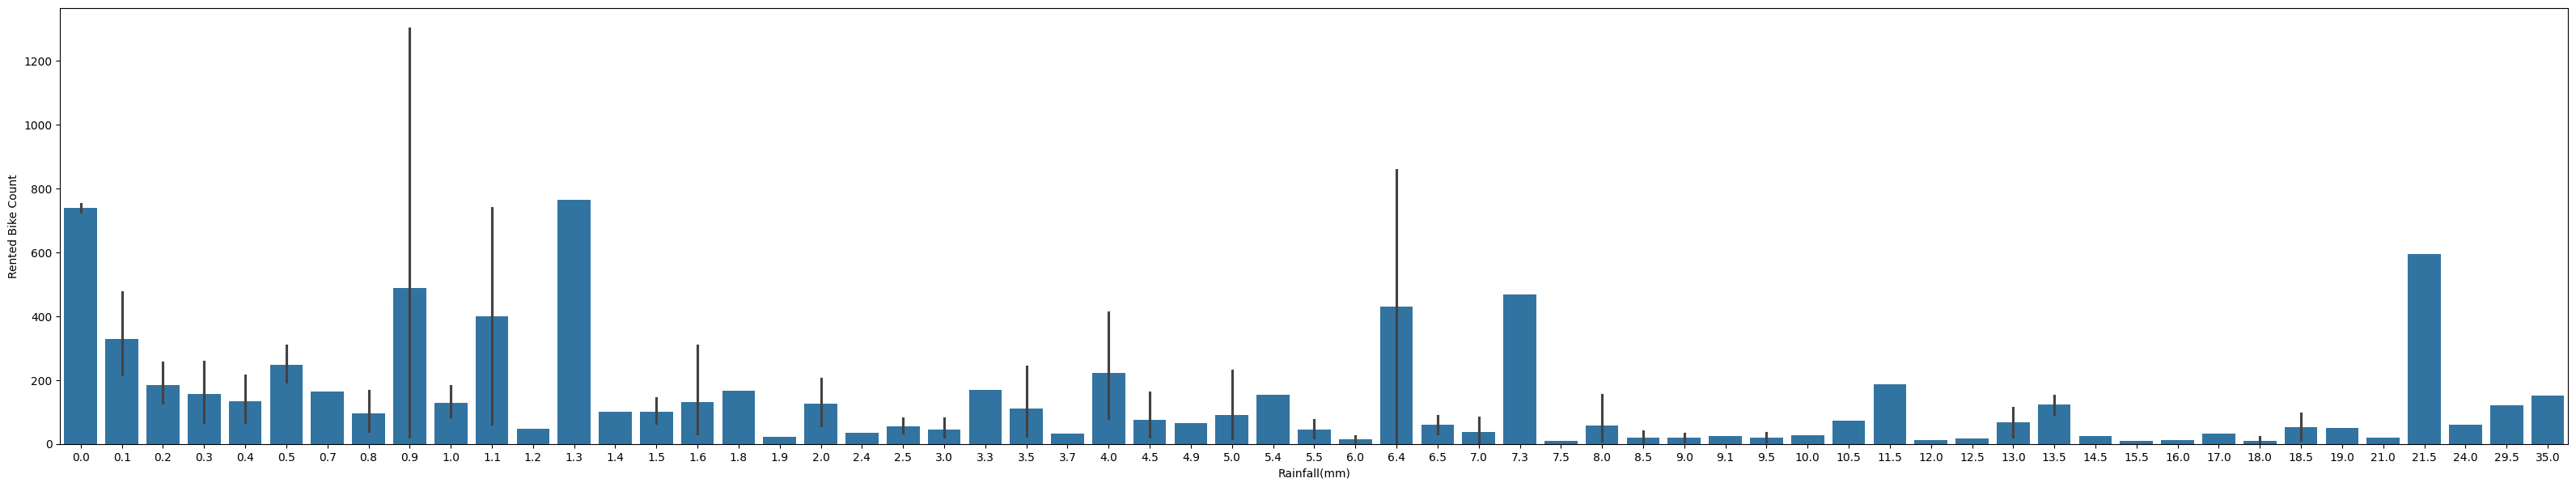

In [17]:
plt.figure(figsize=(40,7))
sns.barplot(x="Rainfall(mm)",y="Rented Bike Count", data=df)

<Axes: xlabel='Snowfall (cm)', ylabel='Rented Bike Count'>

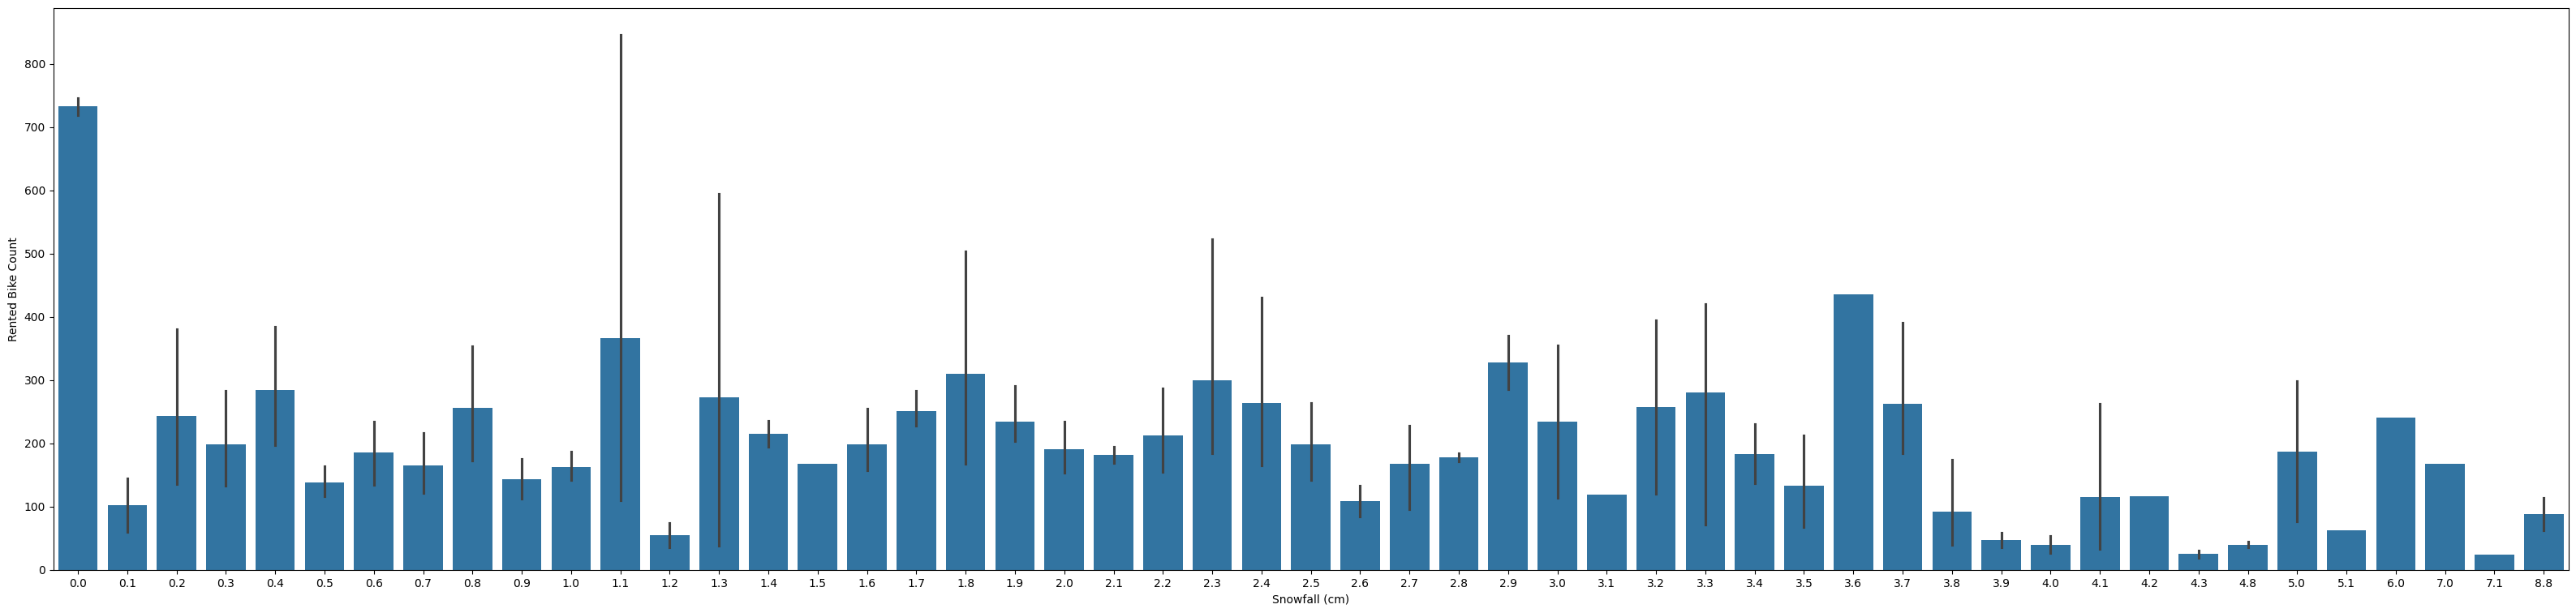

In [18]:
plt.figure(figsize=(40,9))
sns.barplot(x="Snowfall (cm)",y="Rented Bike Count", data=df)

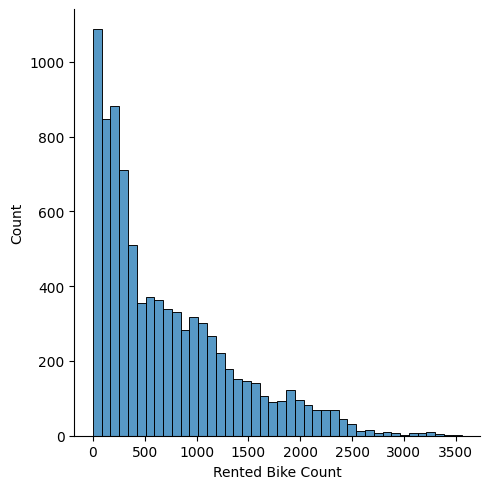

In [19]:
sns.displot(df["Rented Bike Count"])

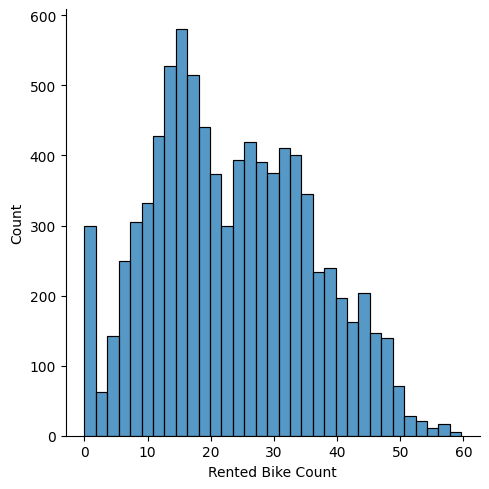

In [20]:
sns.displot(np.sqrt(df["Rented Bike Count"]))

In [21]:
#Skewed Data
df._get_numeric_data().skew().sort_values(ascending=True)

Year                         -2.978262
Visibility (10m)             -0.701786
Dew point temperature(°C)    -0.367298
Temperature(°C)              -0.198326
Month                        -0.010458
Hour                          0.000000
Day                           0.007522
Humidity(%)                   0.059579
Wind speed (m/s)              0.890955
Rented Bike Count             1.153428
Solar Radiation (MJ/m2)       1.504040
Snowfall (cm)                 8.440801
Rainfall(mm)                 14.533232
dtype: float64

In [22]:
df.corr(numeric_only=True)

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,Year
Rented Bike Count,1.000000,4.102573e-01,0.538558,-0.199780,0.121108,0.199280,0.379788,0.261837,-0.123074,-0.141804,2.229091e-02,1.335139e-01,2.151618e-01
Hour,0.410257,1.000000e+00,0.124114,-0.241644,0.285197,0.098753,0.003054,0.145131,0.008715,-0.021516,1.450952e-16,1.749134e-15,2.336763e-14
Temperature(°C),0.538558,1.241145e-01,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405,1.564544e-02,2.161826e-01,3.777958e-01
Humidity(%),-0.199780,-2.416438e-01,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183,-2.904392e-02,1.398748e-01,3.592468e-02
Wind speed (m/s),0.121108,2.851967e-01,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554,-3.197744e-02,-1.567102e-01,-3.780878e-03
Visibility (10m),0.199280,9.875348e-02,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695,-1.017585e-01,6.487420e-02,5.238110e-02
Dew point temperature(°C),0.379788,3.054372e-03,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887,1.525311e-04,2.425519e-01,3.363497e-01
Solar Radiation (MJ/m2),0.261837,1.451309e-01,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301,-2.981839e-03,-3.159544e-02,1.280860e-01
Rainfall(mm),-0.123074,8.714642e-03,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500,-1.623338e-03,1.195810e-02,2.752192e-02
Snowfall (cm),-0.141804,-2.151645e-02,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000,1.020774e-01,5.312091e-02,-2.064178e-01


<Axes: >

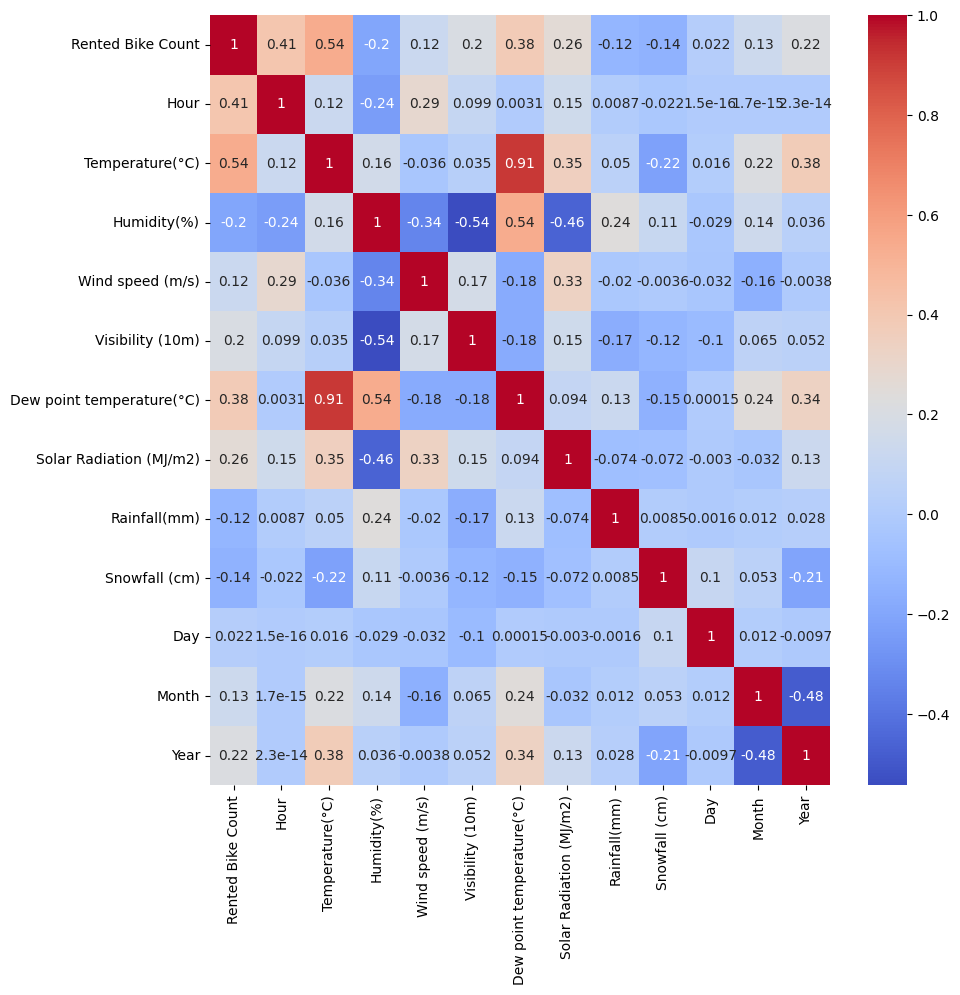

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [24]:
def get_vif(df):
  vif = pd.DataFrame()
  vif["variables"] = df.columns
  vif["VIF"] =[variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
  return vif

In [26]:
df[[i for i in df.describe().columns if i not in not_for_vif]]

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
0,0,-5.2,37,2.2,2000,0.0,0.0,0.0
1,1,-5.5,38,0.8,2000,0.0,0.0,0.0
2,2,-6.0,39,1.0,2000,0.0,0.0,0.0
3,3,-6.2,40,0.9,2000,0.0,0.0,0.0
4,4,-6.0,36,2.3,2000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
8755,19,4.2,34,2.6,1894,0.0,0.0,0.0
8756,20,3.4,37,2.3,2000,0.0,0.0,0.0
8757,21,2.6,39,0.3,1968,0.0,0.0,0.0
8758,22,2.1,41,1.0,1859,0.0,0.0,0.0


In [27]:
df.drop(columns=['Dew point temperature(°C)'], errors='ignore', inplace=True)

In [28]:
#Encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   str    
 10  Holiday                  8760 non-null   str    
 11  Functioning Day          8760 non-null   str    
 12  Weekday                  8760 non-null   str    
 13  Day                      8760 non-null   int32  
 14  Month                    8760 non-n

In [29]:
cat_features = ["Seasons", "Holiday", "Weekday", "Functioning Day"]

In [30]:
df["Holiday"].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [31]:
df["Functioning Day"].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [32]:
df["Seasons"].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [33]:
df["Weekday"].value_counts()

Weekday
Friday       1272
Saturday     1248
Sunday       1248
Monday       1248
Tuesday      1248
Wednesday    1248
Thursday     1248
Name: count, dtype: int64

In [34]:
df["Holiday"] = df["Holiday"].map({"No Holiday":0, "Holiday":1})
df["Functioning Day"] = df["Functioning Day"].map({"Yes":1, "No":0})

In [35]:
df_season = pd.get_dummies(df["Seasons"], drop_first=True)
df_weekday = pd.get_dummies(df["Weekday"], drop_first=True)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   str    
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  Weekday                  8760 non-null   str    
 13  Day                      8760 non-null   int32  
 14  Month                    8760 non-n

In [37]:
df = pd.concat([df, df_season, df_weekday], axis=1)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   str    
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  Weekday                  8760 non-null   str    
 13  Day                      8760 non-null   int32  
 14  Month                    8760 non-n

In [39]:
df.drop(["Seasons", "Weekday"],axis=1, inplace=True)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Holiday                  8760 non-null   int64  
 10  Functioning Day          8760 non-null   int64  
 11  Day                      8760 non-null   int32  
 12  Month                    8760 non-null   int32  
 13  Year                     8760 non-null   int32  
 14  Spring                   8760 non-n

In [41]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,...,Year,Spring,Summer,Winter,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,False,False,False
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,False,False,False
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,False,False,False
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,False,False,False
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,...,2017,False,False,True,False,False,False,False,False,False


In [42]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day',
       'Month', 'Year', 'Spring', 'Summer', 'Winter', 'Monday', 'Saturday',
       'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='str')

In [43]:
df.shape

(8760, 23)

In [44]:
#Split Data for Training and Testing
X = df.drop("Rented Bike Count", axis=1)
Y = df["Rented Bike Count"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2023)

print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (7008, 22)
Shape of Y_train:  (7008,)
Shape of X_test:  (1752, 22)
Shape of Y_test:  (1752,)


In [45]:
#Scaling
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [46]:
X_train[:2]

array([[ 1.51118219,  0.05556521, -2.10940521,  0.46658045,  0.92262892,
        -0.65681529, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -0.41966071, -0.72590612,  0.30459857,  1.74132735, -0.58152447,
        -0.57866842, -0.40630934, -0.40916536, -0.4075004 ,  2.46842407,
        -0.40081071, -0.41367015],
       [ 0.93371229,  1.00382241, -0.25185689,  1.82005277,  0.92262892,
         0.82386154, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -0.41966071, -0.14689974,  0.30459857, -0.57427456,  1.71961809,
        -0.57866842, -0.40630934, -0.40916536, -0.4075004 , -0.40511677,
         2.49494334, -0.41367015]])

In [47]:
sc.mean_

array([1.15323916e+01, 1.28319920e+01, 5.81522546e+01, 1.71738014e+00,
       1.44041795e+03, 5.67796804e-01, 1.52539954e-01, 7.52283105e-02,
       4.92294521e-02, 9.67751142e-01, 1.56847888e+01, 6.50742009e+00,
       2.01791510e+03, 2.48002283e-01, 2.52711187e-01, 2.50856164e-01,
       1.41695205e-01, 1.43407534e-01, 1.42408676e-01, 1.40981735e-01,
       1.38413242e-01, 1.46118721e-01])

In [48]:
sc.scale_

array([6.92676802e+00, 1.20220548e+01, 2.04570722e+01, 1.03437653e+00,
       6.06508248e+02, 8.64469525e-01, 1.18093896e+00, 4.29006703e-01,
       2.16346743e-01, 1.76660323e-01, 8.78039972e+00, 3.45419336e+00,
       2.78737249e-01, 4.31853159e-01, 4.34566730e-01, 4.33505881e-01,
       3.48737257e-01, 3.50487965e-01, 3.49468804e-01, 3.48002709e-01,
       3.45333196e-01, 3.53225198e-01])

In [49]:
#Training ML Model
#Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = lr.predict(X_test)

In [51]:
y_pred

array([  -3.42150244, 1022.33291293, 1474.26387368, ..., 1524.82148315,
        547.90926416,  739.64325466], shape=(1752,))

In [52]:
#Model Evaluation
MSE = mean_squared_error(Y_test, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(Y_test, y_pred)
R2 = r2_score(Y_test, y_pred)

print(f"MSE: {MSE}")
print(f"RMSE: {RMSE}")
print(f"MAE: {MAE}")
print(f"R2: {R2}")

MSE: 186569.98193192578
RMSE: 431.9374745630735
MAE: 330.21078355249136
R2: 0.5429221393038915


In [53]:
def get_metrics(Y_test, y_pred, model_name):
  MSE = mean_squared_error(Y_test, y_pred)
  RMSE = np.sqrt(MSE)
  MAE = mean_absolute_error(Y_test, y_pred)
  R2 = r2_score(Y_test, y_pred)

  print(f" {model_name} : ['MSE': {round(MSE,3)}, 'RMSE' :{round(RMSE,3)}, 'MAE' :{round(MAE,3)}, 'R2' :{round(R2,3)}] ")

In [54]:
get_metrics(Y_test, y_pred, "LinearRegression")

 LinearRegression : ['MSE': 186569.982, 'RMSE' :431.937, 'MAE' :330.211, 'R2' :0.543] 


In [55]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

In [56]:
rir = Ridge().fit(X_train, Y_train)
y_pred_rir = rir.predict(X_test)

lar = Lasso().fit(X_train, Y_train)
y_pred_lar = lar.predict(X_test)

poly = PolynomialFeatures(2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

poly_r = LinearRegression().fit(X_train_poly, Y_train)
y_pred_poly = poly_r.predict(X_test_poly)

svr = SVR().fit(X_train, Y_train)
y_pred_svr = svr.predict(X_test)

knnr = KNeighborsRegressor().fit(X_train, Y_train)
y_pred_knnr = knnr.predict(X_test)

dtr = DecisionTreeRegressor().fit(X_train, Y_train)
y_pred_dtr = dtr.predict(X_test)

rfr = RandomForestRegressor().fit(X_train, Y_train)
y_pred_rfr = rfr.predict(X_test)

xgbr = XGBRegressor().fit(X_train, Y_train)
y_pred_xgbr = xgbr.predict(X_test)

In [57]:
get_metrics(Y_test, y_pred_rir, "Ridge")
get_metrics(Y_test, y_pred_lar, "Lasso")
get_metrics(Y_test, y_pred_poly, "PolynomialFeature")
get_metrics(Y_test, y_pred_svr, "SVR")
get_metrics(Y_test, y_pred_knnr, "KNNR")
get_metrics(Y_test, y_pred_dtr, "DecisionTreeRegressor")
get_metrics(Y_test, y_pred_rfr, "RandomForestRegressor")
get_metrics(Y_test, y_pred_xgbr, "XGBRegressor")

 Ridge : ['MSE': 186567.569, 'RMSE' :431.935, 'MAE' :330.2, 'R2' :0.543] 
 Lasso : ['MSE': 187028.139, 'RMSE' :432.468, 'MAE' :330.257, 'R2' :0.542] 
 PolynomialFeature : ['MSE': 117091.032, 'RMSE' :342.186, 'MAE' :239.644, 'R2' :0.713] 
 SVR : ['MSE': 313071.334, 'RMSE' :559.528, 'MAE' :381.349, 'R2' :0.233] 
 KNNR : ['MSE': 100530.621, 'RMSE' :317.066, 'MAE' :207.508, 'R2' :0.754] 
 DecisionTreeRegressor : ['MSE': 56048.675, 'RMSE' :236.746, 'MAE' :131.259, 'R2' :0.863] 
 RandomForestRegressor : ['MSE': 29738.639, 'RMSE' :172.449, 'MAE' :98.667, 'R2' :0.927] 
 XGBRegressor : ['MSE': 24164.914, 'RMSE' :155.451, 'MAE' :95.454, 'R2' :0.941] 


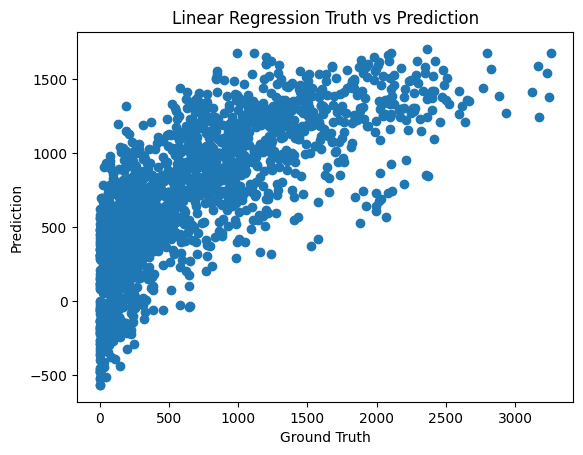

In [58]:
#Visualize Model Prediction
plt.scatter(Y_test, y_pred)
plt.title("Linear Regression Truth vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

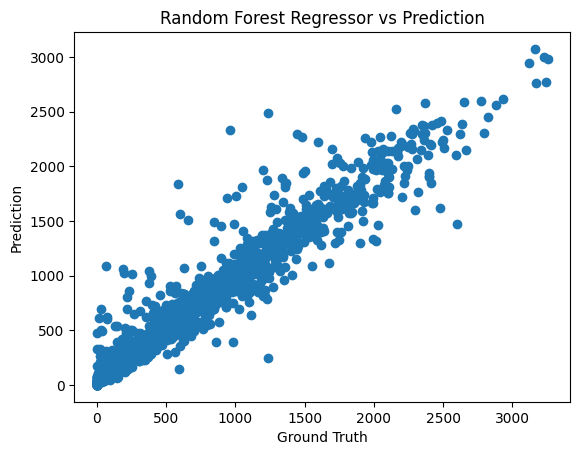

In [59]:
plt.scatter(Y_test, y_pred_rfr)
plt.title("Random Forest Regressor vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

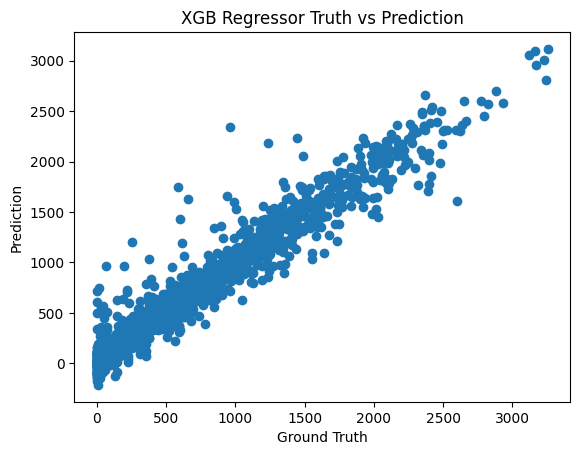

In [60]:
plt.scatter(Y_test, y_pred_xgbr)
plt.title("XGB Regressor Truth vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

In [61]:
#Save ML Best Model
import pickle
import os

dir = r"C:\Users\Rahmah Adnan\Desktop\Model"
model_file_name = "xgboost_regressor_r2_0_941_v1.pkl"
os.makedirs(dir, exist_ok=True)

model_file_path = os.path.join(dir, model_file_name)

pickle.dump(xgbr, open(model_file_path, "wb"))

In [62]:
X_test[0,:]

array([ 1.07807977,  0.22192612,  0.77468297,  1.82005277, -1.26200749,
       -0.25194272, -0.12916836, -0.17535463, -0.22754885, -5.47803337,
       -0.64744078, -0.43640293,  0.30459857,  1.74132735, -0.58152447,
       -0.57866842, -0.40630934, -0.40916536, -0.4075004 ,  2.46842407,
       -0.40081071, -0.41367015])

In [63]:
X_test[1,:]

array([-0.65432992,  1.24504573,  0.23697162, -0.5001855 ,  0.56154562,
       -0.28664608, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        0.94701966,  0.14260346,  0.30459857, -0.57427456,  1.71961809,
       -0.57866842, -0.40630934, -0.40916536, -0.4075004 , -0.40511677,
        2.49494334, -0.41367015])

In [64]:
Y_test

3859       0
5647    1213
6735    1391
374      292
5791    1130
        ... 
1992     195
930      316
5634    2405
3291     164
6416     721
Name: Rented Bike Count, Length: 1752, dtype: int64

In [65]:
#Dump Scaling Parameters
sc_dump_path = r"C:\Users\Rahmah Adnan\Desktop\Model/sc.pkl"
pickle.dump(sc, open(sc_dump_path, "wb"))

In [68]:
#Inference
import pickle
from datetime import datetime
import pandas as pd

model_path = r"C:\Users\Rahmah Adnan\Desktop\Model\xgboost_regressor_r2_0_941_v1.pkl"
model = pickle.load(open(model_path, "rb"))

In [69]:
data = [
    [ 1.07807977,  0.22192612,  0.77468297,  1.82005277, -1.26200749,
        -0.25194272, -0.12916836, -0.17535463, -0.22754885, -5.47803337,
        -0.64744078, -0.43640293,  0.30459857,  1.74132735, -0.58152447,
        -0.57866842, -0.40630934, -0.40916536, -0.4075004 ,  2.46842407,
        -0.40081071, -0.41367015],
    [-0.65432992,  1.24504573,  0.23697162, -0.5001855 ,  0.56154562,
       -0.28664608, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        0.94701966,  0.14260346,  0.30459857, -0.57427456,  1.71961809,
       -0.57866842, -0.40630934, -0.40916536, -0.4075004 , -0.40511677,
        2.49494334, -0.41367015]
]

prediction = model.predict(data)
list(prediction)

[np.float32(111.23919), np.float32(1380.9358)]

In [70]:
#Load SC
sc_dump_path = r"C:\Users\Rahmah Adnan\Desktop\Model/sc.pkl"

sc = pickle.load( open(sc_dump_path, "rb"))

In [71]:
#Users Input
date = "6/06/2026"
hour = 5
temperature = 20
humidity = 60
wind_speed = 80
visibility = 50
solar_radiation = 0.0
rainfall = 0.0
snowfall = 0.0
seasons = "Spring"
holiday = "Holiday"
functioning_day = "No"

In [72]:
#Convert Data into Model Consumable Format

holiday_dic={"No Holiday":0, "Holiday":1}
finctioning_day={"Yes":1, "No":0}

def get_string_to_datetime(date):
  dt = datetime.strptime(date, "%d/%m/%Y")
  return {"day": dt.day, "month": dt.month, "year": dt.year, "weekday": dt.strftime("%A")}

str_to_date = get_string_to_datetime(date)
str_to_date

{'day': 6, 'month': 6, 'year': 2026, 'weekday': 'Saturday'}

In [73]:
u_input_list = [hour, temperature, humidity, wind_speed, visibility, solar_radiation, rainfall, snowfall,
                holiday_dic[holiday], finctioning_day[functioning_day],
                str_to_date["day"], str_to_date["month"], str_to_date["year"]]

features_name = [ 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
                 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day', 'Month', 'Year' ]

df_u_input = pd.DataFrame([u_input_list], columns=features_name)
df_u_input

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Day,Month,Year
0,5,20,60,80,50,0.0,0.0,0.0,1,0,6,6,2026


In [74]:
def season_to_df(seasons):
  seasons_cols = ['Spring', 'Summer', 'Winter']
  seasons_data = np.zeros((1, len(seasons_cols)), dtype = int)
  df_seasons = pd.DataFrame(seasons_data, columns=seasons_cols)
  if seasons in seasons_cols:
    df_seasons[seasons] = 1
  return df_seasons

df_seasons = season_to_df(seasons)
df_seasons

,Spring,Summer,Winter
0,1,0,0


In [75]:
def days_df(week_day):
  days_names = ['Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
  days_name_data = np.zeros((1, len(days_names)), dtype = int)
  df_days = pd.DataFrame(days_name_data, columns=days_names)

  if week_day in days_names:
    df_days[week_day] = 1
  return df_days
df_days= days_df(str_to_date["weekday"])
df_days

,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,0,1,0,0,0,0


In [76]:
df_for_pred = pd.concat([df_u_input, df_seasons, df_days], axis=1)
df_for_pred

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,...,Year,Spring,Summer,Winter,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,5,20,60,80,50,0.0,0.0,0.0,1,0,...,2026,1,0,0,0,1,0,0,0,0


In [77]:
sc_data_for_pred = sc.transform(df_for_pred)
sc_data_for_pred

array([[-0.94306487,  0.59623817,  0.09032306, 75.6809708 , -2.29249636,
        -0.65681529, -0.12916836, -0.17535463,  4.39466079, -5.47803337,
        -1.1030009 , -0.14689974, 29.00546301,  1.74132735, -0.58152447,
        -0.57866842, -0.40630934,  2.44399966, -0.4075004 , -0.40511677,
        -0.40081071, -0.41367015]])

In [78]:
#Prediction in Deployment

print(f"Rented Bike Demand on date: {date}, and Time: {hour} is: {round(model.predict(sc_data_for_pred).tolist()[0])}")

Rented Bike Demand on date: 6/06/2026, and Time: 5 is: -66
